## Exercise: Decision trees

#### In this exercise, we will test our knowledge of the fundamental concepts of decision trees by implementing a decision tree regression model and analysing its performance metrics.

#### By the end of this exercise,you should be able to:
##### - Implement a decision tree regression model

In [1]:
# Read the database, and clean the data using the processing modules we built.

import re
import numpy as np
import pandas as pd
from field_data_processor import FieldDataProcessor
# from weather_data_processor import WeatherDataProcessor
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

config_params = {
    "sql_query": """
            SELECT *
            FROM geographic_features
            LEFT JOIN weather_features USING (Field_ID)
            LEFT JOIN soil_and_crop_features USING (Field_ID)
            LEFT JOIN farm_management_features USING (Field_ID)
            """,
    "db_path": 'sqlite:///Maji_Ndogo_farm_survey_small.db',
    "columns_to_rename": {'Annual_yield': 'Crop_type', 'Crop_type': 'Annual_yield'},
    "values_to_rename": {'cassaval': 'cassava', 'wheatn': 'wheat', 'teaa': 'tea'},
    "weather_csv_path": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_station_data.csv",
    "weather_mapping_csv": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_data_field_mapping.csv",
    "regex_patterns" : {
            'Rainfall': r'(\d+(\.\d+)?)\s?mm',
            'Temperature': r'(\d+(\.\d+)?)\s?C',
            'Pollution_level': r'=\s*(-?\d+(\.\d+)?)|Pollution at \s*(-?\d+(\.\d+)?)'
            },
}
# Ignoring the field data for now.
field_processor = FieldDataProcessor(config_params)
field_processor.process()
field_df = field_processor.df

# We're not going to use the weather data this time, so we'll ignore it.
# weather_processor = WeatherDataProcessor(config_params)
# weather_processor.process()
# weather_df = weather_processor.weather_df

dataset = field_df.drop("Weather_station", axis=1)

2026-07-28 18:05:48,956 - data_ingestion - INFO - Database engine created successfully.
2026-07-28 18:05:49,142 - data_ingestion - INFO - Query executed successfully.
2026-07-28 18:05:49,142 - field_data_processor.FieldDataProcessor - INFO - Sucessfully loaded data.
2026-07-28 18:05:49,150 - field_data_processor.FieldDataProcessor - INFO - Swapped columns: Annual_yield with Crop_type
2026-07-28 18:05:50,041 - data_ingestion - INFO - CSV file read successfully from the web.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# validate the data
# !pip install pytest
dataset.to_csv('sampled_field_df.csv', index=False)

import os
field_csv_path = 'sampled_field_df.csv'

# Delete sampled_field_df.csv if it exists
if os.path.exists(field_csv_path):
    os.remove(field_csv_path)
    print(f'Deleted {field_csv_path}')
else:
    print(f'{field_csv_path} does not exist.')

Deleted sampled_field_df.csv


## Exercises

### Exercise 1:

#### To begin our exploration of the dataset, we will use a decision tree to explore how all of the variables affect our crop yields.

#### Given our dataset containing information on environmental factors and crop yields, how can we train a decision tree model to predict crop yields accurately?

#### Fit a decision tree regressor model to the entire dataset.

#### Use all predictor variables (excluding non-numeric columns) to predict `Standard_yield`.

#### Set the `max_Depth` to 4 and the `random_state` 42 for reproducibility.

#### Consider the **MSE** and **R²** values, how effective is the decision tree in predicting crop yields using all of our variables

In [6]:
field_df

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield,Weather_station
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,8.526684e-02,1.3,0.751354,cassava,0.577964,4
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,3.996838e-01,2.2,1.069865,cassava,0.486302,0
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,3.580286e-01,3.4,2.208801,tea,0.649647,0
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,2.866871e-01,2.4,1.277635,cassava,0.532348,1
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,4.319027e-02,1.5,0.832614,wheat,0.555076,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5649,11472,681.36145,-7.358371,-6.254369,Rural_Akatsi,16.213196,885.7,-4.3,33.4,14.55,0.61,Sandy,5.741063,3.286828e-01,1.1,0.609930,potato,0.554482,4
5650,19660,667.02120,-3.154559,-4.475046,Rural_Kilimani,2.397553,501.1,-4.8,32.1,13.65,0.54,Sandy,5.445833,1.602583e-01,8.7,3.812289,maize,0.438194,3
5651,41296,670.77900,-14.472861,-6.110221,Rural_Hawassa,7.636470,1586.6,-3.8,33.4,14.80,0.64,Volcanic,5.385873,8.221326e-09,2.1,1.681629,tea,0.800776,2
5652,33090,429.48840,-14.653089,-6.984116,Rural_Hawassa,13.944720,1272.2,-6.2,34.6,14.20,0.63,Silt,5.562508,6.917245e-10,1.3,0.659874,cassava,0.507595,2


In [9]:
field_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5654 entries, 0 to 5653
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Field_ID           5654 non-null   int64  
 1   Elevation          5654 non-null   float64
 2   Latitude           5654 non-null   float64
 3   Longitude          5654 non-null   float64
 4   Location           5654 non-null   object 
 5   Slope              5654 non-null   float64
 6   Rainfall           5654 non-null   float64
 7   Min_temperature_C  5654 non-null   float64
 8   Max_temperature_C  5654 non-null   float64
 9   Ave_temps          5654 non-null   float64
 10  Soil_fertility     5654 non-null   float64
 11  Soil_type          5654 non-null   object 
 12  pH                 5654 non-null   float64
 13  Pollution_level    5654 non-null   float64
 14  Plot_size          5654 non-null   float64
 15  Annual_yield       5654 non-null   float64
 16  Crop_type          5654 

In [10]:
X = field_df.select_dtypes(include=['int64', 'float64']).drop('Standard_yield', axis=1)
y = field_df['Standard_yield']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [16]:
tree = DecisionTreeRegressor(max_depth=4, random_state=42)

In [17]:
tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [18]:
y_pred = tree.predict(X_test)

In [20]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': tree.feature_importances_
})

In [21]:
print(importance)

              feature  importance
0            Field_ID    0.000000
1           Elevation    0.155704
2            Latitude    0.000000
3           Longitude    0.222629
4               Slope    0.000000
5            Rainfall    0.196753
6   Min_temperature_C    0.031570
7   Max_temperature_C    0.000000
8           Ave_temps    0.000000
9      Soil_fertility    0.000000
10                 pH    0.084501
11    Pollution_level    0.298858
12          Plot_size    0.000000
13       Annual_yield    0.009985
14    Weather_station    0.000000


In [22]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [23]:
print('MSE:', mse)
print('R² Score:', r2)

MSE: 0.00783374750449001
R² Score: 0.39578883967035594


### Exercise 2

#### While the model shows some predictive capability with a moderate R² value, there is still room for improvement, particularly in reducing the MSE and potentially increasing the expanatory power of the model. This can be achieved through further feature selection, hyperparameter tuning, or exploring alternative modelling techniques.

#### Let's start with feature selection. What environmental factors have the highest correlation with crop yields, and how can we use this information to improve the predictive performance of our model?

#### Conduct feature selection using a **correlation matrix** to select relevant features for predicting `Standard_yield`

#### Visualise the matrix to better identify the features with the highest correlation with `Standard_yield`

#### Regarding features to retain and eliminate, what do the results suggest? Have you thought about the independent features that might be correlated?

In [31]:
field_corr_df = field_df.select_dtypes(include=['int64', 'float64'])

In [32]:
corr_matrix = field_corr_df.corr()

In [33]:
corr_matrix

,Field_ID,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,pH,Pollution_level,Plot_size,Annual_yield,Standard_yield,Weather_station
Field_ID,1.000000,0.021496,0.036000,-0.006767,0.002649,-0.030996,0.013839,-0.011910,-0.000757,-0.023096,-0.013109,-0.010793,0.005633,0.008008,0.030802,0.025267
Elevation,0.021496,1.000000,0.546737,0.345139,0.081837,-0.238518,0.956418,-0.605884,0.203061,-0.146844,-0.430787,0.285086,-0.032261,0.005033,0.129248,-0.046020
Latitude,0.036000,0.546737,1.000000,0.257728,0.103381,-0.756442,0.337544,-0.340948,-0.077763,-0.566838,-0.220201,0.289556,-0.064183,-0.045701,0.061724,0.086784
Longitude,-0.006767,0.345139,0.257728,1.000000,-0.078865,0.146665,0.398923,-0.223253,0.119329,0.071705,-0.315035,0.476562,0.065011,0.088318,0.085343,-0.359949
Slope,0.002649,0.081837,0.103381,-0.078865,1.000000,-0.131472,0.044370,-0.046567,-0.012279,0.550326,-0.087969,0.010879,-0.603773,-0.571007,0.056991,-0.076474
Rainfall,-0.030996,-0.238518,-0.756442,0.146665,-0.131472,1.000000,0.052469,0.155806,0.233366,0.752914,0.025182,-0.198268,0.092198,0.098114,0.039217,-0.165485
Min_temperature_C,0.013839,0.956418,0.337544,0.398923,0.044370,0.052469,1.000000,-0.576769,0.278994,0.072797,-0.435366,0.235310,-0.005503,0.034617,0.144233,-0.096443
Max_temperature_C,-0.011910,-0.605884,-0.340948,-0.223253,-0.046567,0.155806,-0.576769,1.000000,0.623555,0.099502,0.255306,-0.161467,0.018017,-0.011637,-0.111649,0.031340
Ave_temps,-0.000757,0.203061,-0.077763,0.119329,-0.012279,0.233366,0.278994,0.623555,1.000000,0.186633,-0.116527,0.035383,0.015914,0.019449,0.006786,-0.055455
Soil_fertility,-0.023096,-0.146844,-0.566838,0.071705,0.550326,0.752914,0.072797,0.099502,0.186633,1.000000,-0.035415,-0.160151,-0.320810,-0.294160,0.070205,-0.190353


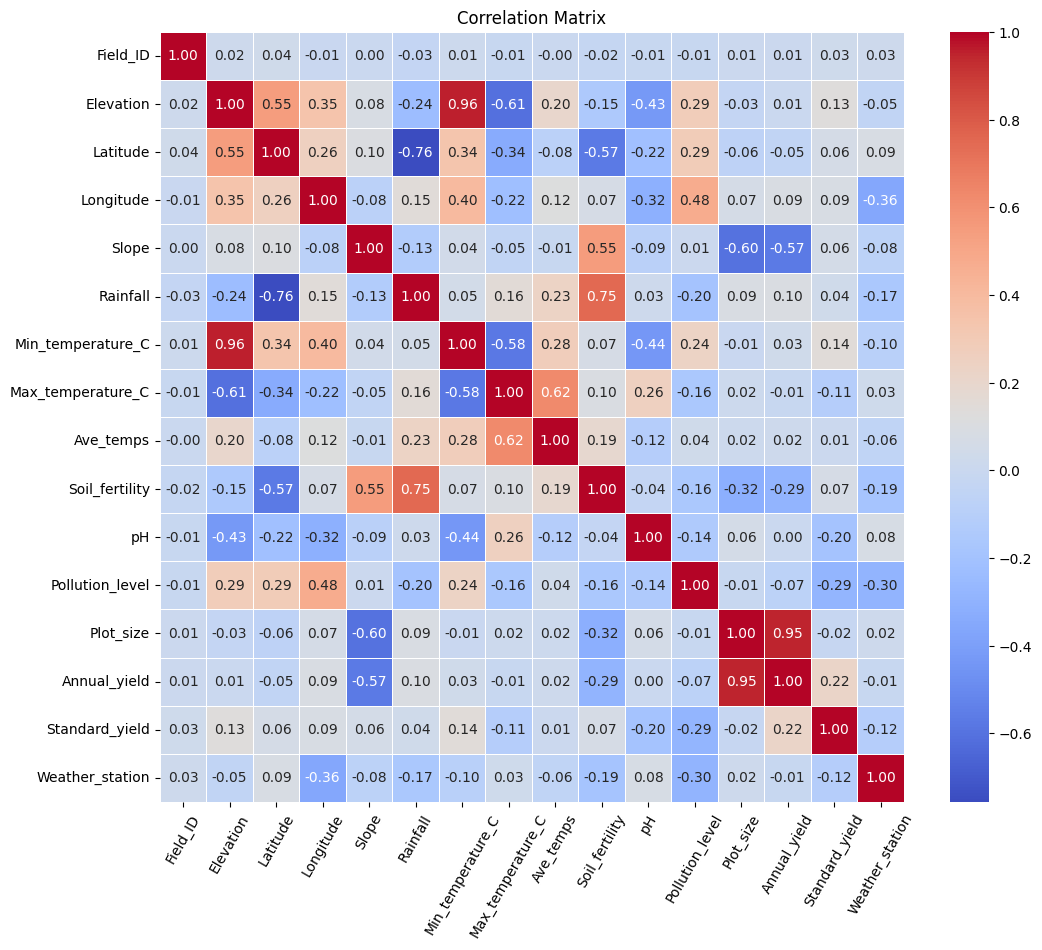

In [39]:
# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', fmt='.2f', linewidth=0.5, annot=True)
plt.title('Correlation Matrix')
plt.xticks(rotation=60)
plt.show()

### Exercise 3

#### Now that we know which features could work best for our model, let's run our model again on a reduced dataset.

#### Reduce the dataset to only include `Pollution_level`, `Min_temperature_C`, `Longitude`, and `pH`.

#### Refit the decision tree regressor model using the reduced dataset and evaluate the model's performance on the test set to determine if there's an improvement in MSE and R² values.

#### Does reducing the dataset lead to an improvement in the predictive performance of our model?

#### Run the model on different combinations of the reduced dataset. Is there a combination of variables or a single variable that improves the MSE and R²

In [42]:
new_filter_df = field_df[['Pollution_level', 'Min_temperature_C', 'Longitude', 'pH']]
new_y = field_df['Standard_yield']

In [45]:
X_train_nfd, X_test_nfd, y_train_nfd, y_test_nfd = train_test_split(
    new_filter_df,
    new_y,
    test_size=0.25,
    random_state=42
)

In [46]:
tree_nfd = DecisionTreeRegressor(max_depth=4, random_state=42)

In [48]:
tree_nfd.fit(X_train_nfd, y_train_nfd)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [50]:
y_pred_nfd = tree_nfd.predict(X_test_nfd)

In [51]:
importance = pd.DataFrame({
    'feature': new_filter_df.columns,
    'importance': tree_nfd.feature_importances_
})

In [52]:
print(importance)

             feature  importance
0    Pollution_level    0.387228
1  Min_temperature_C    0.071544
2          Longitude    0.283123
3                 pH    0.258106


In [53]:
mse = mean_squared_error(y_test_nfd, y_pred_nfd)
r2 = r2_score(y_test_nfd, y_pred_nfd)

In [54]:
print('MSE:', mse)
print('R² Score:', r2)

MSE: 0.008833273895051126
R² Score: 0.31869610724888275


### Exercise 4

#### Now that we have attempted feature engineering, let's move on to parameter tuning. What is the optimal depth for the decision tree model that maximises predictive performance while avoiding overfitting?

#### Use a loop to fit decision tree models with depths ranging from 1 to 10 and assess the MSE and R² scores for each depth. Analyse the results to identify the depth that maximises R² while avoiding significant increases in MSE, indicating optimal model complexity

In [55]:
depths = []
mse_scores = []
r2_scores = []

In [56]:
for depth in range(1, 11):
    tree_nfd_lp = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree_nfd_lp.fit(X_train_nfd, y_train_nfd)
    y_pred_nfd_lp = tree_nfd_lp.predict(X_test_nfd)
    mse_nfd_lp = mean_squared_error(y_test_nfd, y_pred_nfd_lp)
    r2_score_nfd_lp = r2_score(y_test_nfd, y_pred_nfd_lp)
    
    depths.append(depth)
    mse_scores.append(mse_nfd_lp)
    r2_scores.append(r2_score_nfd_lp)

In [57]:
results = pd.DataFrame({
    'Tree_depth': depths,
    'MSE': mse_scores,
    'R2': r2_scores
})

In [58]:
print(results)

   Tree_depth       MSE        R2
0           1  0.011440  0.117642
1           2  0.009731  0.249446
2           3  0.008958  0.309055
3           4  0.008833  0.318696
4           5  0.008669  0.331329
5           6  0.008363  0.354967
6           7  0.008730  0.326696
7           8  0.009122  0.296463
8           9  0.009364  0.277787
9          10  0.009750  0.247976
